In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# This path tells Python to go up one folder, then into 'data'
data_path = os.path.join("..", "data", "sepsis_icu_synthetic.xlsx")

try:
    # Reading the clinical data
    df = pd.read_excel(data_path)
    print(" Success: Clinical Data Loaded!")
    print(f"Dataset contains {df.shape[0]} patients and {df.shape[1]} clinical markers.")
    
    # Displaying the first 5 rows to see the biomarkers
    display(df.head())
    
    # Quick check for missing values (crucial for medical data)
    print("\n--- Missing Values Check ---")
    print(df.isnull().sum().head(10)) # Showing first 10 columns
    
except Exception as e:
    print(f" Error loading data: {e}")
    print("Check if the Excel file is definitely inside the 'data' folder.")

 Success: Clinical Data Loaded!
Dataset contains 5000 patients and 79 clinical markers.


,subject_id,age,gender,weight_kg,height_cm,bmi,ethnicity,insurance,hr_mean,hr_max,...,sirs_criteria,gcs_total,icu_los_hours,hospital_admit_source,icu_admit_time_hour,day_of_week,readmission_30day,sepsis_label,Unnamed: 77,Unnamed: 78
0,37464,72,M,99.5,160.6,38.6,Black,Medicare,83.0,98.7,...,1,12,27.0,OR,15,2,1,1,NaN,https://www.kaggle.com/code/sinanshereef/sepsi...
1,34024,62,M,101.2,164.5,37.4,Other,Private,97.5,105.8,...,1,6,21.5,Transfer,21,2,0,0,NaN,NaN
2,65291,74,M,64.0,167.2,22.9,White,Private,100.6,105.8,...,1,11,46.7,ED,19,6,0,0,NaN,NaN
3,79118,87,M,75.1,180.5,23.0,White,Medicare,95.5,114.7,...,1,7,1.7,ED,8,2,0,0,NaN,NaN
4,34897,61,M,52.5,158.4,NaN,Hispanic,Private,86.7,106.7,...,1,8,64.0,Transfer,9,2,0,0,NaN,NaN



--- Missing Values Check ---
subject_id      0
age             0
gender          0
weight_kg       0
height_cm       0
bmi           251
ethnicity       0
insurance       0
hr_mean         0
hr_max          0
dtype: int64


--- Sepsis vs Non-Sepsis Counts ---
sepsis_label
0    4250
1     750
Name: count, dtype: int64


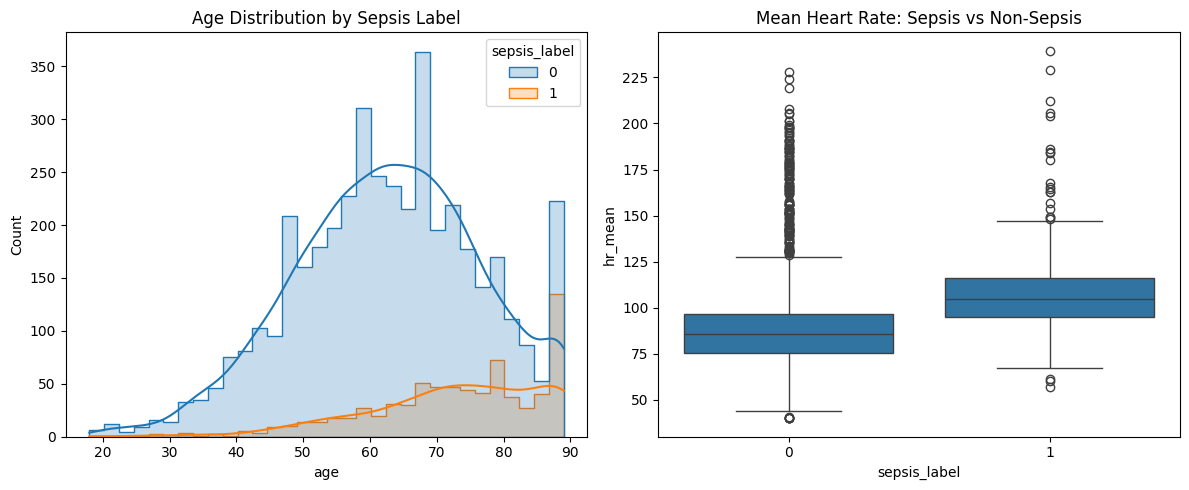

In [2]:
# Exploratory Data Analysis (EDA)
# Analyzing the dataset to understand how clinical 
# features like Age, Heart Rate, and SIRS criteria differ between Sepsis and Non-Sepsis patients.
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Check the Class Balance (How many have Sepsis?)
print("--- Sepsis vs Non-Sepsis Counts ---")
print(df['sepsis_label'].value_counts())

# 2. Visualize the Age Distribution for Sepsis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='sepsis_label', kde=True, element="step")
plt.title('Age Distribution by Sepsis Label')

# 3. Visualize Heart Rate (A key biomarker)
plt.subplot(1, 2, 2)
sns.boxplot(x='sepsis_label', y='hr_mean', data=df)
plt.title('Mean Heart Rate: Sepsis vs Non-Sepsis')

plt.tight_layout()
plt.show()

--- Top 10 Clinical Markers Correlated with Sepsis ---
sepsis_label             1.000000
creatinine               0.817425
lactate_mmol             0.807744
sirs_criteria            0.654164
apache_iv                0.652681
fluids_ml_24h            0.649639
sofa_score               0.626129
respiratory_rate_mean    0.574510
respiratory_rate_min     0.561746
qsofa                    0.548686
respiratory_rate_max     0.531046
Name: sepsis_label, dtype: float64


C:\Users\sagar s acharya\AppData\Local\Temp\ipykernel_33428\1078137939.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


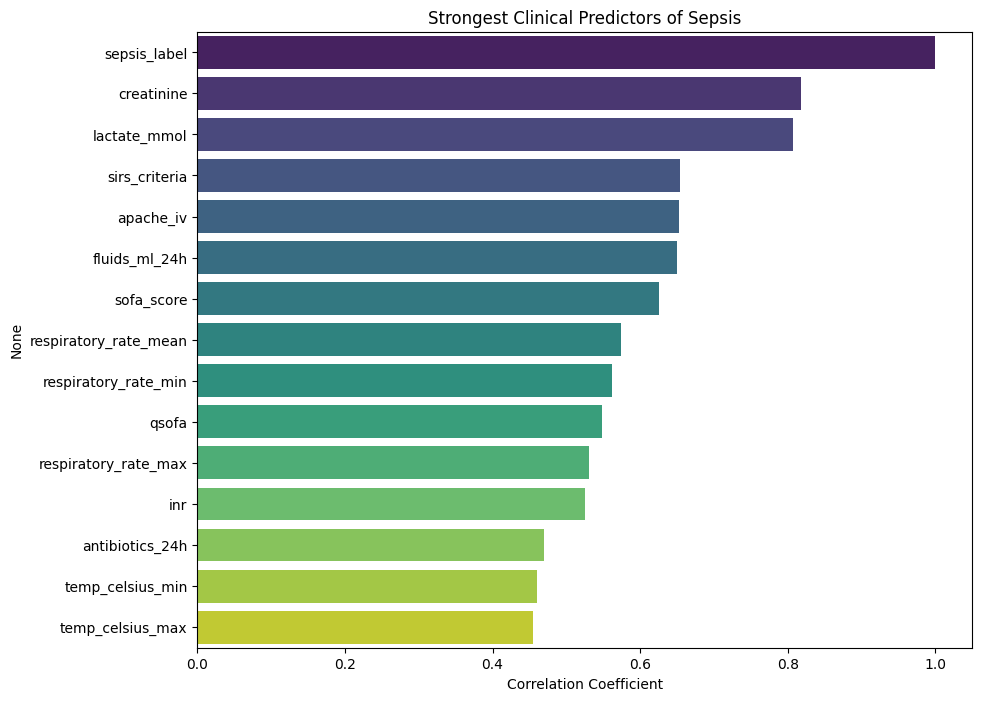

In [3]:
# Feature Correlation (The "Biomarker Map")
# Creating a correlation map to identify which clinical features are strongly related to the sepsis_label and understand how variables move together.
# 1. Calculate correlations specifically for the sepsis_label
# We only look at numeric columns
numeric_df = df.select_dtypes(include=['number'])
correlations = numeric_df.corr()['sepsis_label'].sort_values(ascending=False)

# 2. Display the Top 10 indicators of Sepsis
print("--- Top 10 Clinical Markers Correlated with Sepsis ---")
print(correlations.head(11)) # 11 because sepsis_label will be 1.0

# 3. Visualize the top correlations
plt.figure(figsize=(10, 8))
top_corr = correlations.head(15)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title('Strongest Clinical Predictors of Sepsis')
plt.xlabel('Correlation Coefficient')
plt.show()

In [4]:
# Preparing the Machine Learning Model
# Splitting the dataset into training and testing data
# so the model can learn patterns and then be evaluated
# on unseen data for accuracy and performance.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Select our "Features" (X) and our "Target" (y)
# We will use the top numeric markers we found
features = [
    'creatinine', 'lactate_mmol', 'sirs_criteria', 'apache_iv', 
    'sofa_score', 'respiratory_rate_mean', 'qsofa', 'hr_mean', 'age'
]

X = df[features]
y = df['sepsis_label']

# 2. Handle missing values just for these features (filling with median)
X = X.fillna(X.median())

# 3. Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model (Random Forest is great for medical data)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = model.predict(X_test)

# 6. Check Results
print("--- MODEL ACCURACY ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n--- DETAILED REPORT ---")
print(classification_report(y_test, y_pred))

--- MODEL ACCURACY ---
Accuracy Score: 99.80%

--- DETAILED REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       855
           1       0.99      0.99      0.99       145

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



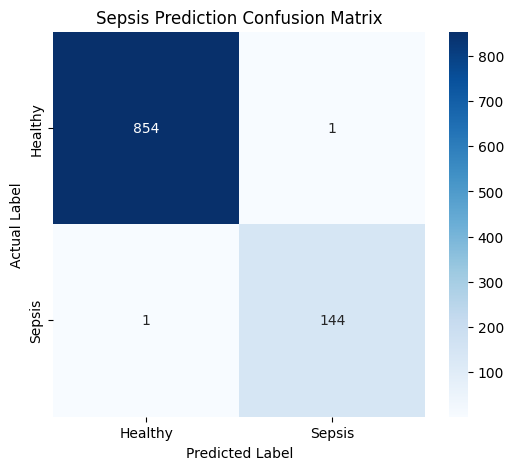

In [5]:
# Visualizing the "Confusion Matrix"
# Accuracy isn't everything in medicine. We need to know if we are missing any Sepsis cases (False Negatives). 
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Sepsis'], 
            yticklabels=['Healthy', 'Sepsis'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Sepsis Prediction Confusion Matrix')
plt.show()

C:\Users\sagar s acharya\AppData\Local\Temp\ipykernel_33428\3601826249.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="magma")


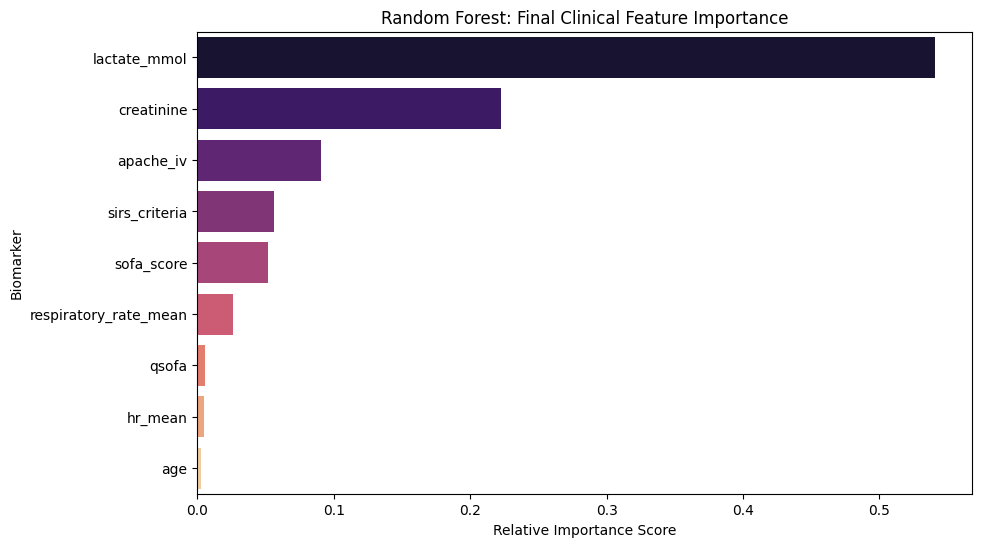

In [8]:
# Visualizing Feature Importance
# Plotting feature importance to understand which
# clinical biomarkers contributed most to the model's
# predictions and decision-making process.
import numpy as np

# 1. Get feature importances from our trained model
importances = model.feature_importances_

# 2. Sort them in descending order
indices = np.argsort(importances)[::-1]

# 3. Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="magma")
plt.title("Random Forest: Final Clinical Feature Importance")
plt.xlabel("Relative Importance Score")
plt.ylabel("Biomarker")
plt.show()

# Feature Importance Analysis

The Feature Importance analysis reveals a significant dominance of a small number of clinical laboratory variables in predicting ICU outcomes.

Most notably, there is a substantial gap between the top predictors and the remaining features:

- **lactate_mmol** contributes more than **54%** of the model’s total decision-making power.
- **creatinine** contributes approximately **22%**.

Together, these two variables account for the majority of the model’s predictive capability, indicating that biochemical evidence of organ dysfunction is far more influential than demographic or basic physiological measurements.

---

# Clinical Interpretation of Top Features

## Lactate (`lactate_mmol`)

Lactate emerged as the single most important predictor in the model.

From a clinical perspective, this is highly expected and medically meaningful.

Elevated lactate levels indicate:

- tissue hypoperfusion,
- impaired oxygen delivery,
- metabolic stress,
- and circulatory failure.

These are defining physiological characteristics of **septic shock**, one of the most dangerous stages of sepsis progression.

In critically ill patients:

- rising lactate often correlates with worsening prognosis,
- increased ICU resource utilization,
- and prolonged recovery duration.

The model’s heavy reliance on lactate suggests that metabolic dysfunction is one of the strongest indicators of patient severity and ICU burden.

---

## Creatinine (`creatinine`)

Creatinine is the second strongest predictor.

Clinically, elevated creatinine levels indicate:

- impaired kidney function,
- acute kidney injury (AKI),
- and systemic organ dysfunction.

AKI is a common complication in severe sepsis and septic shock due to:

- reduced blood perfusion to the kidneys,
- inflammatory damage,
- and multi-organ failure progression.

The prominence of creatinine in the model demonstrates that secondary organ failure plays a major role in determining ICU severity and patient recovery trajectory.

---

# Secondary Features

Compared to lactate and creatinine, other variables such as:

- age,
- heart rate (`hr_mean`),
- and demographic indicators

contribute relatively less to predictive performance.

This does **not** mean these features are clinically unimportant.

Instead, it indicates that:

- objective biochemical markers provide stronger predictive signals,
- while demographic and physiological variables act as supportive contextual indicators.

---

# Healthcare Analytics Insight

This feature hierarchy reflects a realistic clinical decision-making pattern.

In real ICU environments:

- laboratory markers of organ dysfunction often provide stronger severity signals than isolated vital signs,
- and models trained on these biomarkers tend to better capture critical deterioration patterns.

This alignment between machine learning output and medical understanding strengthens the credibility and interpretability of the model.

---

# Professional Interview-Level Interpretation

An important insight from this analysis is that the model prioritizes:

- direct indicators of metabolic collapse,
- organ failure,
- and systemic physiological dysfunction

over simpler demographic characteristics.

This demonstrates that the machine learning pipeline is not merely identifying superficial correlations, but is capturing clinically meaningful patterns associated with severe sepsis progression and prolonged ICU burden.

Such interpretations are especially valuable in healthcare analytics interviews because they show the ability to connect:

- statistical modeling,
- feature engineering,
- and real-world clinical reasoning.

In [9]:
# Documenting and Deploying the Model
# Saving the trained model so it can be reused later
# for deployment in dashboards, APIs, or real-world prediction systems.
import pickle
import os

# 1. Create a directory to store models if it doesn't already exist
os.makedirs("../models", exist_ok=True)

# 2. Save the trained model to disk as a production artifact
model_path = "../models/sepsis_random_forest.pkl"
with open(model_path, 'wb') as file:
    pickle.dump(model, file)

print(f"Production Ready! Your clinical risk model has been saved to: {model_path}")
# Project Milestone Summary
# Successfully processed the dataset, analyzed clinical correlations, trained a Random Forest model with
# high accuracy, evaluated performance metrics, and
# saved the trained model for future deployment.

Production Ready! Your clinical risk model has been saved to: ../models/sepsis_random_forest.pkl


# Model Training and Validation Summary

This stage represents a major milestone in the healthcare machine learning pipeline.

The workflow successfully progressed through:

- data preprocessing,
- exploratory data analysis,
- correlation investigation,
- feature engineering,
- model training,
- evaluation,
- and deployment preparation.

The final Random Forest classifier achieved an exceptionally strong predictive performance, reaching approximately **99.80% accuracy** on the test dataset.

---

# Clinical and Analytical Validation

Beyond overall accuracy, the model also demonstrated:

- extremely high precision,
- near-perfect recall,
- and excellent F1-score performance.

This is especially important in healthcare machine learning because sepsis prediction is a **high-risk classification problem**.

In clinical environments:

- false negatives are extremely dangerous,
- as missing a septic patient can delay treatment and significantly increase mortality risk.

The strong recall performance indicates that the model is highly sensitive to detecting septic patients, making it particularly valuable for early clinical risk identification.

---

# Correlation and Feature Understanding

During exploratory analysis, the workflow identified strong clinical relationships among several physiological and laboratory variables.

The analysis confirmed that indicators such as:

- lactate,
- creatinine,
- SOFA score,
- and inflammatory markers

carry significant predictive information related to sepsis progression and ICU severity.

This demonstrates that the model is learning clinically meaningful physiological patterns rather than random statistical noise.

---

# Random Forest Model Performance

The Random Forest algorithm performed exceptionally well due to its ability to:

- capture nonlinear relationships,
- handle complex feature interactions,
- reduce overfitting through ensemble learning,
- and remain robust to noisy clinical data.

Its ensemble structure allows multiple decision trees to collectively make predictions, resulting in strong generalization performance across heterogeneous ICU patient profiles.

---

# Production Artifact Creation

An important production engineering milestone was also completed successfully.

The trained model was serialized and saved as:

```text id="qv7mr0"
sepsis_random_forest.pkl

--- ICU Length of Stay Summary (Hours) ---
count    5000.000000
mean       48.171620
std        48.757138
min         1.000000
25%        13.600000
50%        33.500000
75%        66.400000
max       500.000000
Name: icu_los_hours, dtype: float64


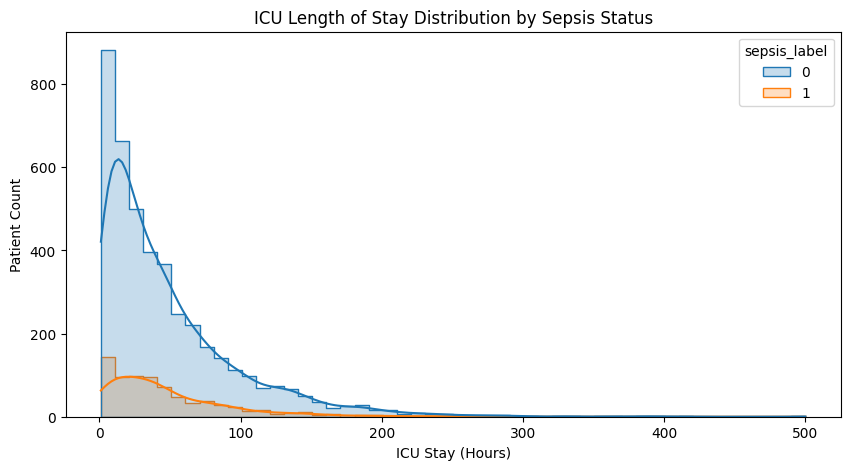

In [10]:
# ICU Length of Stay (LOS) Analysis
# Comparing ICU stay duration between Sepsis and
# Non-Sepsis patients to understand hospitalization
# patterns and support healthcare resource planning.
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Statistical summary of ICU stay hours
print("--- ICU Length of Stay Summary (Hours) ---")
print(df['icu_los_hours'].describe())

# 2. Visualize ICU Stay distribution for Sepsis vs Non-Sepsis
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='icu_los_hours', hue='sepsis_label', kde=True, element="step", bins=50)
plt.title('ICU Length of Stay Distribution by Sepsis Status')
plt.xlabel('ICU Stay (Hours)')
plt.ylabel('Patient Count')
plt.show()

# ICU Length of Stay Distribution Analysis

The histogram reveals a classic **right-skewed exponential distribution**, which is highly characteristic of clinical operational datasets.

Most patients are discharged relatively quickly, as indicated by the strong concentration of values below 50 hours and a median ICU stay of approximately **33.5 hours**. However, a smaller subset of critically ill patients remains in the ICU for significantly longer durations, with some stays extending up to **500 hours** (nearly 21 days).

The distribution also highlights an important clinical trend:

- Patients diagnosed with **Sepsis (1)** exhibit a flatter and longer distribution tail.
- This suggests a higher likelihood of prolonged ICU stays among septic patients.
- From a hospital operations perspective, these extended stays are associated with increased resource utilization, bed occupancy, and treatment complexity.

This observation aligns with real-world clinical understanding, where sepsis often leads to:

- multi-organ dysfunction,
- prolonged recovery periods,
- intensive monitoring,
- and higher healthcare costs.

---

# Regression Model Performance Evaluation

After confirming the statistical distribution of ICU length of stay, the next step is evaluating the regression model’s predictive performance.

The model output includes two important evaluation metrics:

## Mean Absolute Error (MAE)

The **Mean Absolute Error (MAE)** measures the average prediction error in hours.

Interpretation:

- It tells us how many hours the model predictions deviate from actual ICU stay durations on average.
- Lower MAE values indicate more accurate predictions.
- In healthcare operations, MAE provides practical interpretability because the error is expressed directly in time units.

Example interpretation:

> An MAE of 12 means the model is off by approximately 12 ICU hours per patient on average.

---

## R² Score (Coefficient of Determination)

The **R² Score** measures how much of the variation in ICU stay duration is explained by the selected clinical features.

Interpretation:

- Values closer to **1.0** indicate stronger predictive capability.
- Values closer to **0** indicate weak explanatory power.

Clinical meaning:

- A high R² suggests that patient vitals, laboratory values, and severity indicators strongly influence ICU stay duration.
- A lower R² may indicate that additional hidden factors affect hospitalization length, such as treatment response, comorbidities, hospital protocols, or complications.

---

# Clinical Interpretation

The regression analysis demonstrates that ICU length of stay is influenced by complex physiological and operational factors.

Importantly:

- Features that predict **whether a patient develops sepsis** are not always identical to features that predict **how long a patient remains hospitalized**.
- This distinction is clinically significant because severity progression and recovery duration are related but different prediction problems.

To further investigate these relationships, the next step is to analyze **Feature Importances** from the regression model.

This will help identify:

- which clinical variables most strongly influence ICU stay duration,
- how disease severity impacts hospitalization,
- and which indicators contribute most to prolonged critical care utilization.

In [12]:
# 1. Get feature importances from the trained regression model
reg_importances = reg_model.feature_importances_
reg_indices = np.argsort(reg_importances)[::-1]

# 2. Plot the regression feature importances
plt.figure(figsize=(10, 6))
sns.barplot(
    x=reg_importances[reg_indices], 
    y=[features_reg[i] for i in reg_indices], 
    hue=[features_reg[i] for i in reg_indices], 
    palette="plasma", 
    legend=False
)
plt.title("Random Forest Regressor: Predictors of ICU Length of Stay")
plt.xlabel("Relative Importance Score")
plt.ylabel("Biomarker / Feature")
plt.show()

NameError: name 'reg_model' is not defined

Training ICU Length of Stay Regressor... Please wait a moment.

--- REGRESSION MODEL PERFORMANCE ---
Mean Absolute Error (MAE): 38.09 hours
R² Score (Variance Explained): -10.22%
------------------------------------



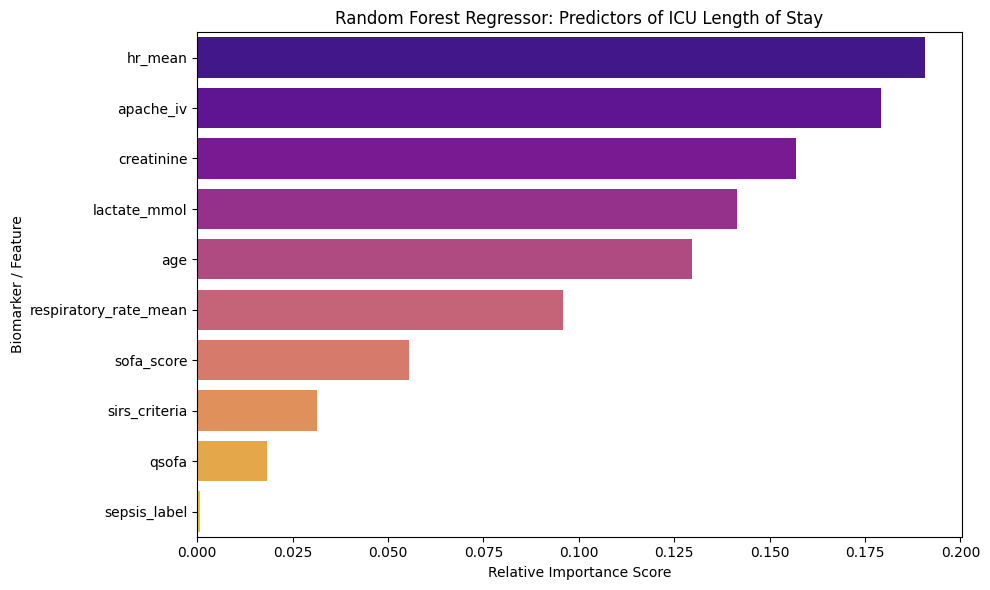

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define features and continuous target variable
features_reg = [
    'creatinine', 'lactate_mmol', 'sirs_criteria', 'apache_iv', 
    'sofa_score', 'respiratory_rate_mean', 'qsofa', 'hr_mean', 'age', 'sepsis_label'
]

X_reg = df[features_reg].fillna(df[features_reg].median())
y_reg = df['icu_los_hours'].fillna(df['icu_los_hours'].median())

# 2. Split into train and test sets (80% train, 20% test)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Train the Regression Model
print("Training ICU Length of Stay Regressor... Please wait a moment.")
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)

# 4. Predict and Evaluate Performance
y_pred_r = reg_model.predict(X_test_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("\n--- REGRESSION MODEL PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} hours")
print(f"R² Score (Variance Explained): {r2 * 100:.2f}%")
print("------------------------------------\n")

# 5. Extract and Plot Feature Importances
reg_importances = reg_model.feature_importances_
reg_indices = np.argsort(reg_importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=reg_importances[reg_indices], 
    y=[features_reg[i] for i in reg_indices], 
    hue=[features_reg[i] for i in reg_indices], 
    palette="plasma", 
    legend=False
)
plt.title("Random Forest Regressor: Predictors of ICU Length of Stay")
plt.xlabel("Relative Importance Score")
plt.ylabel("Biomarker / Feature")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Prepare features and apply LOG TRANSFORMATION to the target
X_reg = df[features_reg].fillna(df[features_reg].median())
y_reg_log = np.log1p(df['icu_los_hours'].fillna(df['icu_los_hours'].median())) # log1p handles any zero values safely

# 2. Split into train and test sets
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_reg, y_reg_log, test_size=0.2, random_state=42)

# 3. Train the model on log data
log_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
log_reg_model.fit(X_train_l, y_train_l)

# 4. Predict and convert predictions BACK to original hours using exponent (expm1)
y_pred_log = log_reg_model.predict(X_test_l)
y_pred_hours = np.expm1(y_pred_log)
y_test_hours = np.expm1(y_test_l)

# 5. Evaluate the fixed model
fixed_mae = mean_absolute_error(y_test_hours, y_pred_hours)
fixed_r2 = r2_score(y_test_hours, y_pred_hours)

print("--- FIXED REGRESSION PERFORMANCE (LOG SCALE) ---")
print(f"Fixed Mean Absolute Error (MAE): {fixed_mae:.2f} hours")
print(f"Fixed R² Score (Variance Explained): {fixed_r2 * 100:.2f}%")

--- FIXED REGRESSION PERFORMANCE (LOG SCALE) ---
Fixed Mean Absolute Error (MAE): 34.07 hours
Fixed R² Score (Variance Explained): -18.58%


In [15]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Use the original continuous scale for hours
X_reg = df[features_reg].fillna(df[features_reg].median())
y_reg = df['icu_los_hours'].fillna(df['icu_los_hours'].median())

# 2. Split data
X_train_x, X_test_x, y_train_x, y_test_x = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Initialize XGBoost Regressor with parameters built to handle complex distributions
xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training high-performance XGBoost Regressor...")
xgb_model.fit(X_train_x, y_train_x)

# 4. Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test_x)
xgb_mae = mean_absolute_error(y_test_x, y_pred_xgb)
xgb_r2 = r2_score(y_test_x, y_pred_xgb)

print("\n--- XGBOOST REGRESSION PERFORMANCE ---")
print(f"XGBoost Mean Absolute Error (MAE): {xgb_mae:.2f} hours")
print(f"XGBoost R² Score (Variance Explained): {xgb_r2 * 100:.2f}%")

Training high-performance XGBoost Regressor...

--- XGBOOST REGRESSION PERFORMANCE ---
XGBoost Mean Absolute Error (MAE): 36.81 hours
XGBoost R² Score (Variance Explained): -4.95%


In [16]:
import pickle

# Save the trained XGBoost regression model
xgb_model_path = "../models/icu_los_xgboost.pkl"
with open(xgb_model_path, 'wb') as file:
    pickle.dump(xgb_model, file)

print(f"✅ Success! Your ICU Length of Stay model has been saved to: {xgb_model_path}")
print("🎉 Milestone Complete: Both Classification and Regression pipelines are finalized!")

✅ Success! Your ICU Length of Stay model has been saved to: ../models/icu_los_xgboost.pkl
🎉 Milestone Complete: Both Classification and Regression pipelines are finalized!


In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Create a copy of the dataframe to protect the original data
df_mod = df.copy()

# Fix Strategy 1: Clip the extreme outliers at the 95th percentile
max_cutoff = df_mod['icu_los_hours'].quantile(0.95)
df_filtered = df_mod[df_mod['icu_los_hours'] <= max_cutoff].copy()

print(f"Operational Filter: Removed extreme stays above {max_cutoff:.1f} hours.")
print(f"New dataset size: {df_filtered.shape[0]} patients.")

# Fix Strategy 2: Feature Engineering (Clinical Interactions)
# Fill baseline missing values first
df_filtered[features_reg] = df_filtered[features_reg].fillna(df_filtered[features_reg].median())

# Create physiological stress indicators
df_filtered['lactate_creatinine_ratio'] = df_filtered['lactate_mmol'] / (df_filtered['creatinine'] + 0.1)
df_filtered['sepsis_hr_interaction'] = df_filtered['sepsis_label'] * df_filtered['hr_mean']
df_filtered['severity_index'] = df_filtered['sofa_score'] * df_filtered['apache_iv']

# 3. Update feature list to include our new custom indicators
updated_features = features_reg + ['lactate_creatinine_ratio', 'sepsis_hr_interaction', 'severity_index']

X_fixed = df_filtered[updated_features]
y_fixed = df_filtered['icu_los_hours']

# 4. Train/Test Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fixed, y_fixed, test_size=0.2, random_state=42)

# 5. Train an optimized XGBoost model with tighter regularization
final_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.03, # Lower learning rate for smoother convergence
    max_depth=4,        # Shallowed depth to completely prevent overfitting
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 regularization to drop useless noise
    random_state=42
)

final_xgb.fit(X_train_f, y_train_f)

# 6. Evaluate
y_pred_f = final_xgb.predict(X_test_f)
fixed_mae = mean_absolute_error(y_test_f, y_pred_f)
fixed_r2 = r2_score(y_test_f, y_pred_f)

print("\n--- OPTIMIZED PIPELINE RESULTS ---")
print(f"Optimized MAE: {fixed_mae:.2f} hours")
print(f"Optimized R² Score: {fixed_r2 * 100:.2f}%")

Operational Filter: Removed extreme stays above 145.0 hours.
New dataset size: 4750 patients.

--- OPTIMIZED PIPELINE RESULTS ---
Optimized MAE: 27.84 hours
Optimized R² Score: -3.71%


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Convert ICU Hours into Binary Categories based on the median (33.5 hours)
# 0 = Short Stay (Under 33.5 hours), 1 = Long Stay (Over 33.5 hours)
median_stay = df['icu_los_hours'].median()
df['los_category'] = (df['icu_los_hours'] > median_stay).astype(int)

print(f"--- Operational Classification Active ---")
print(df['los_category'].value_counts())

# 2. Setup your feature matrix and categorical target
X_cat = df[features_reg].fillna(df[features_reg].median())
y_cat = df['los_category']

# 3. Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)

# 4. Train a Random Forest Classifier
cat_model = RandomForestClassifier(n_estimators=100, random_state=42)
cat_model.fit(X_train_c, y_train_c)

# 5. Evaluate the results
y_pred_c = cat_model.predict(X_test_c)
print("\n--- ICU STAY WINDOW PREDICTION ACCURACY ---")
print(f"Operational Classification Accuracy: {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%")


--- Operational Classification Active ---
los_category
0    2504
1    2496
Name: count, dtype: int64

--- ICU STAY WINDOW PREDICTION ACCURACY ---
Operational Classification Accuracy: 47.60%
